In [57]:
%matplotlib inline
%config IPython.matplotlib.backend = "retina"
from matplotlib import rcParams
rcParams["figure.dpi"] = 150
rcParams["savefig.dpi"] = 150

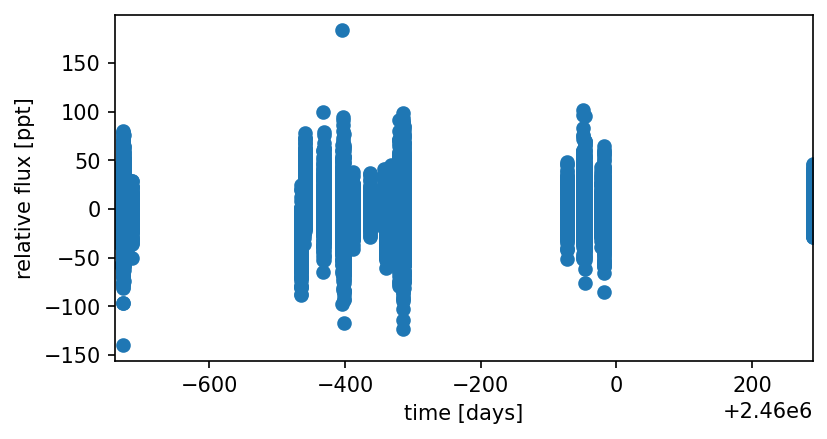

In [58]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy import units as u
import pandas as pd

df = pd.read_csv('/Users/mrvarshney/Codes/ARIES/star_files_3_csv/Final_1820_Photometry.csv', delimiter='\t')
t = df["JD"]
y = df["Differential_Magnitude"]
t = df["JD"].to_numpy()
y = df["Differential_Magnitude"].to_numpy()

m = np.isfinite(t) & np.isfinite(y)

t = t[m]
y = y[m]

# Convert mag → pseudo-flux if needed for BLS
y = 10 ** (-0.4 * y)
y = (y / np.median(y) - 1) * 1e3


fig, ax = plt.subplots(1, 1, sharex=True, figsize=(6, 3))
ax.scatter(t, y)
ax.set_xlim(t.min(), t.max())
ax.set_xlabel("time [days]")
ax.set_ylabel("relative flux [ppt]");

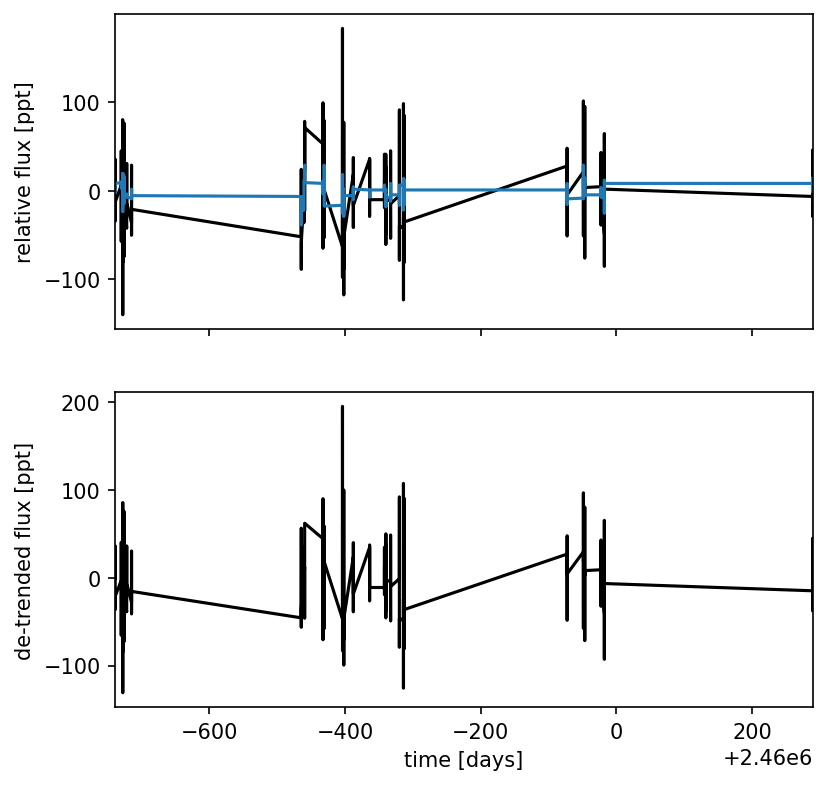

In [59]:
from scipy.signal import medfilt
trend = medfilt(y, 45)
mu = np.median(y)
y_filt =(y - trend)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
ax = axes[0]
ax.plot(t, y, "k")
ax.plot(t, trend)
ax.set_ylabel("relative flux [ppt]")

ax = axes[1]
ax.plot(t, y_filt, "k")
ax.set_xlim(t.min(), t.max())
ax.set_xlabel("time [days]")
ax.set_ylabel("de-trended flux [ppt]");

In [60]:
import numpy as np
import astropy.units as u
from astropy.timeseries import BoxLeastSquares

# Convert time to Quantity (days)
t_q = t * u.day

# Duration grid (in days)
durations = np.linspace(0.05, 0.2, 10) * u.day
# Build BLS model
bls = BoxLeastSquares(t_q, y_filt)

# Run autopower (modern API)
results = bls.autopower(
    durations,
    frequency_factor=1.5,
    minimum_period=2.0 * u.day,
    maximum_period=3.0 * u.day
)

# Inspect results
print(results)


          depth: array([0.95340138, 0.96123708, 0.95637789, ..., 4.04024163, 4.04024163,
       4.03143522], shape=(2350056,))
      depth_err: array([0.02142895, 0.02143107, 0.02143319, ..., 0.05719207, 0.05719207,
       0.05719207], shape=(2350056,))
      depth_snr: array([44.49127826, 44.85249969, 44.62134562, ..., 70.64338714,
       70.64338714, 70.48940762], shape=(2350056,))
       duration: <Quantity [0.185, 0.185, 0.185, ..., 0.05 , 0.05 , 0.05 ] d>
 log_likelihood: array([1383.45871725, 1405.83059008, 1391.19582785, ..., 2570.95950365,
       2570.95950365, 2559.76401396], shape=(2350056,))
      objective: 'likelihood'
         period: <Quantity [2.        , 2.00000028, 2.00000057, ..., 2.99999844, 2.99999908,
           2.99999972] d>
          power: array([1383.45871725, 1405.83059008, 1391.19582785, ..., 2570.95950365,
       2570.95950365, 2559.76401396], shape=(2350056,))
   transit_time: <Quantity [2459262.287569, 2459262.287569, 2459262.287569, ...,
           2459

In [61]:
bls1 = BoxLeastSquares(t_q, y_filt)

results1 = bls1.autopower(
    durations,
    minimum_period=20.0 * u.day,
    maximum_period=30.0 * u.day,
    frequency_factor=1.5
)

idx1 = np.argmax(results1.power)

P1   = results1.period[idx1]
t01  = results1.transit_time[idx1]
d1   = results1.duration[idx1]

print(f"Primary period: {P1.value:.5f} d")


Primary period: 21.52763 d


In [62]:
in_transit_1 = bls1.transit_mask(
    t_q,
    period=P1,
    duration=2 * d1,   # buffer to remove ingress/egress
    transit_time=t01
)

t_resid = t_q[~in_transit_1]
y_resid = y_filt[~in_transit_1]


In [63]:
bls2 = BoxLeastSquares(t_resid, y_resid)

results2 = bls2.autopower(
    durations,
    minimum_period=20 * u.day,
    maximum_period=30 * u.day,
    frequency_factor=1.5
)

idx2 = np.argmax(results2.power)

P2   = results2.period[idx2]
t02  = results2.transit_time[idx2]
d2   = results2.duration[idx2]

print(f"Secondary period: {P2.value:.5f} d")


Secondary period: 22.05442 d


In [64]:
print("Period ratio P2 / P1 =", (P2 / P1).value)


Period ratio P2 / P1 = 1.024470446967669


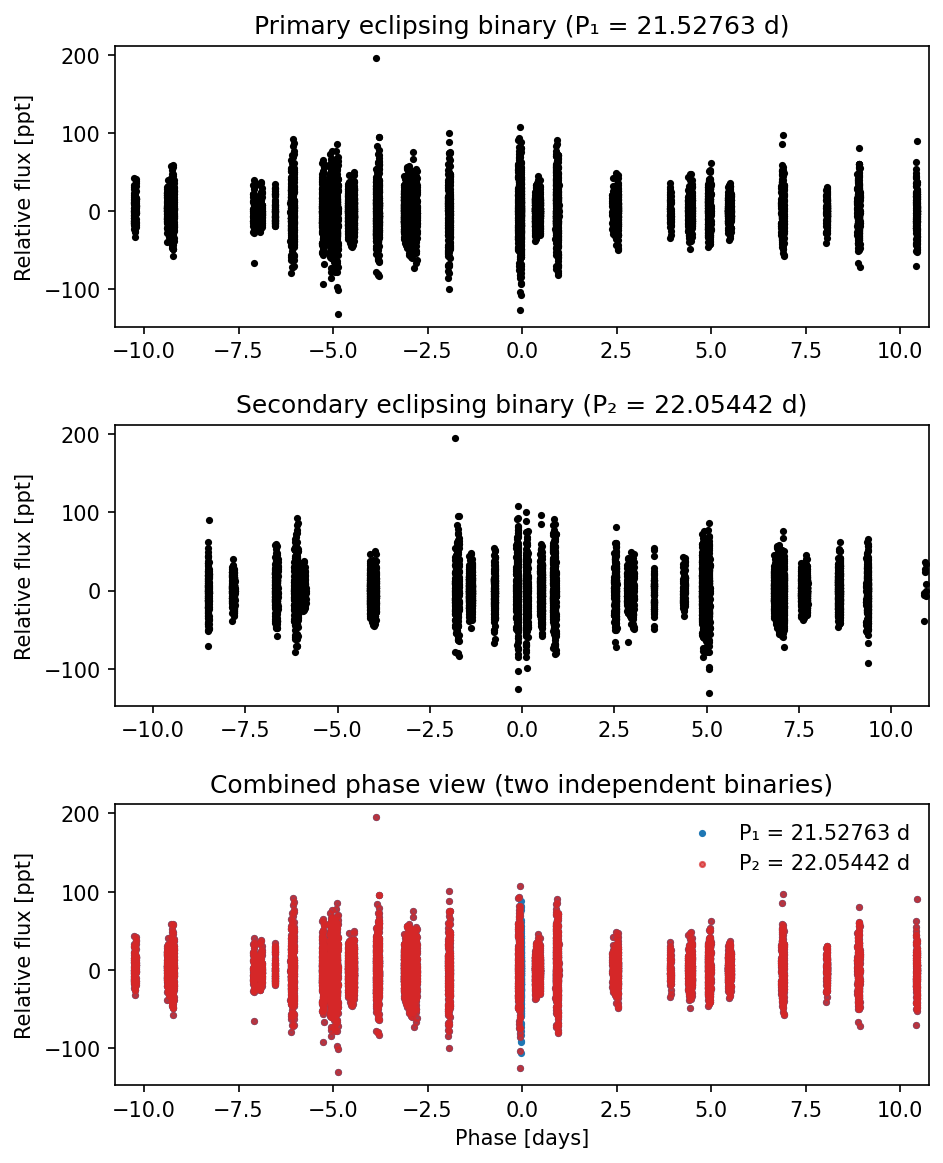

In [65]:
def phase_fold(t, P, t0):
    return (t - t0 + 0.5 * P) % P - 0.5 * P
import matplotlib.pyplot as plt
import astropy.units as u
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharey=True)
fig.subplots_adjust(hspace=0.35)

ax = axes[0]

phase1 = phase_fold(t_q, P1, t01)

ax.scatter(
    phase1.to_value(u.day),
    y_filt,
    s=6,
    color="black"
)

ax.set_xlim(-0.5 * P1.value, 0.5 * P1.value)
ax.set_ylabel("Relative flux [ppt]")
ax.set_title(f"Primary eclipsing binary (P₁ = {P1.value:.5f} d)")

ax = axes[1]

phase2 = phase_fold(t_resid, P2, t02)

ax.scatter(
    phase2.to_value(u.day),
    y_resid,
    s=6,
    color="black"
)

ax.set_xlim(-0.5 * P2.value, 0.5 * P2.value)
ax.set_ylabel("Relative flux [ppt]")
ax.set_title(f"Secondary eclipsing binary (P₂ = {P2.value:.5f} d)")

ax = axes[2]

# Primary folded on P1
ax.scatter(
    phase1.to_value(u.day),
    y_filt,
    s=6,
    color="tab:blue",
    label=f"P₁ = {P1.value:.5f} d"
)

# Secondary folded on P1 (shows incoherence)
phase2_on_P1 = phase_fold(t_resid, P1, t01)

ax.scatter(
    phase2_on_P1.to_value(u.day),
    y_resid,
    s=6,
    color="tab:red",
    label=f"P₂ = {P2.value:.5f} d",
    alpha=0.7
)

ax.set_xlim(-0.5 * P1.value, 0.5 * P1.value)
ax.set_xlabel("Phase [days]")
ax.set_ylabel("Relative flux [ppt]")
ax.set_title("Combined phase view (two independent binaries)")
ax.legend(frameon=False)

plt.show()
